# Variant Analysis

The objective of this analysis is to identify candidate sequence variants within enriched targeted regions and evaluate whether they may represent known polymorphisms, potential pathogenic variants, or technical artifacts.

Because these data are derived from targeted small RNA sequencing rather than DNA sequencing, variant interpretation is performed cautiously. RNA-based variant evidence can be affected by uneven transcript abundance, allele-specific expression, mapping ambiguity, RNA editing, reverse-transcription artifacts, and amplification bias. Therefore, variants identified here are treated as candidate events requiring external annotation and validation.

In [2]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bam_dir = Path("../data/bam")
bam_files = sorted(bam_dir.glob("*.bam"))

fig_dir = Path("../results/figures")
table_dir = Path("../results/tables")
variant_dir = Path("../results/variants")

variant_dir.mkdir(parents=True, exist_ok=True)

bam_files

[PosixPath('../data/bam/sample1.bam'),
 PosixPath('../data/bam/sample2.bam'),
 PosixPath('../data/bam/sample3.bam')]

In [4]:
regions_bed = Path("../results/tables/top_shared_enriched_regions_nochr.bed")

ref_fasta = Path("../genomes/hg19_nochr.fa")
ref_fasta.exists()

True

In [5]:
# Create no-"chr" BED file if it does not already exist
if not regions_bed.exists():
    cmd = (
        "sed 's/^chr//' "
        "../results/tables/top_shared_enriched_regions.bed "
        "> ../results/tables/top_shared_enriched_regions_nochr.bed"
    )
    subprocess.run(cmd, shell=True, check=True)


### Initial Variant Calling

I used `bcftools mpileup` and `bcftools call` to perform first-pass variant calling on each BAM file independently. Reads were filtered using minimum mapping quality (`-q 20`) and base quality (`-Q 20`) thresholds to reduce low-confidence variant evidence.

The resulting calls are treated as candidate variants rather than validated clinical calls.

The initial variant-calling attempt failed because the BAM files use chromosome names without the `chr` prefix, while the UCSC hg19 reference FASTA uses `chr`-prefixed sequence names. I therefore generated a coordinate-compatible reference FASTA with matching chromosome names.

Variant calling was also restricted to the recurrent enriched target regions rather than performed genome-wide. This is appropriate for a targeted sequencing assay and prevents unnecessary computation over genomic regions with no expected coverage.

In [6]:
# Call variants only within enriched target regions
for bam_file in bam_files:
    sample = bam_file.stem
    vcf_out = variant_dir / f"{sample}.target_regions.raw.vcf.gz"
    
    cmd = (
        f"bcftools mpileup "
        f"-f {ref_fasta} "
        f"-R {regions_bed} "
        f"-q 20 -Q 20 "
        f"{bam_file} "
        f"| bcftools call -mv -Oz -o {vcf_out}"
    )
    
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
    subprocess.run(["bcftools", "index", "-f", str(vcf_out)], check=True)

bcftools mpileup -f ../genomes/hg19_nochr.fa -R ../results/tables/top_shared_enriched_regions_nochr.bed -q 20 -Q 20 ../data/bam/sample1.bam | bcftools call -mv -Oz -o ../results/variants/sample1.target_regions.raw.vcf.gz


Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample1.bam.bai
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


bcftools mpileup -f ../genomes/hg19_nochr.fa -R ../results/tables/top_shared_enriched_regions_nochr.bed -q 20 -Q 20 ../data/bam/sample2.bam | bcftools call -mv -Oz -o ../results/variants/sample2.target_regions.raw.vcf.gz


Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample2.bam.bai
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


bcftools mpileup -f ../genomes/hg19_nochr.fa -R ../results/tables/top_shared_enriched_regions_nochr.bed -q 20 -Q 20 ../data/bam/sample3.bam | bcftools call -mv -Oz -o ../results/variants/sample3.target_regions.raw.vcf.gz


Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[W::hts_idx_load3] The index file is older than the data file: ../data/bam/sample3.bam.bai
[mpileup] 1 samples in 1 input files
[mpileup] maximum number of reads per input file set to -d 250


In [7]:
for vcf in sorted(variant_dir.glob("*.target_regions.raw.vcf.gz")):
    print("=" * 80)
    print(vcf.name)
    
    result = subprocess.run(
        ["bcftools", "view", "-H", str(vcf)],
        capture_output=True,
        text=True,
        check=True
    )
    
    n_variants = len(result.stdout.strip().splitlines()) if result.stdout.strip() else 0
    print("Number of candidate variants:", n_variants)

sample1.target_regions.raw.vcf.gz
Number of candidate variants: 11
sample2.target_regions.raw.vcf.gz
Number of candidate variants: 14
sample3.target_regions.raw.vcf.gz
Number of candidate variants: 9


In [8]:
variant_rows = []

for vcf in sorted(variant_dir.glob("*.target_regions.raw.vcf.gz")):
    sample = vcf.name.split(".")[0]
    
    result = subprocess.run(
        ["bcftools", "query", "-f", "%CHROM\t%POS\t%REF\t%ALT\t%QUAL\t%DP\n", str(vcf)],
        capture_output=True,
        text=True,
        check=True
    )
    
    for line in result.stdout.strip().splitlines():
        chrom, pos, ref, alt, qual, dp = line.split("\t")
        variant_rows.append({
            "sample": sample,
            "chrom": chrom,
            "pos": int(pos),
            "ref": ref,
            "alt": alt,
            "qual": float(qual),
            "depth": int(dp)
        })

variants_df = pd.DataFrame(variant_rows)

variants_df.to_csv(table_dir / "candidate_variants_target_regions.csv", index=False)

variants_df.head()

,sample,chrom,pos,ref,alt,qual,depth
0,sample1,19,41762525,A,G,7.30814,2
1,sample1,19,41762670,T,C,37.09330,8
2,sample1,11,69456901,G,C,9.75140,5
3,sample1,3,12641425,T,C,4.91707,13
4,sample1,3,12641874,T,C,21.36120,23


### Candidate Variant Counts

Target-restricted variant calling identified a small number of candidate variants in each sample:

- sample1: 11 variants
- sample2: 14 variants
- sample3: 9 variants

This is consistent with a targeted sequencing assay covering a limited number of enriched loci. These variants are treated as candidate calls because RNA-derived variant evidence can be affected by expression level, mapping ambiguity, and amplification bias.

### Variant Filtering

Initial candidate variant calls included several low-depth or low-quality events. To reduce likely technical artifacts, I applied simple filters requiring read depth ≥10 and QUAL ≥20.

In [9]:
filtered_variants = variants_df[
    (variants_df["depth"] >= 10) &
    (variants_df["qual"] >= 20)
].copy()

filtered_variants.to_csv(
    table_dir / "candidate_variants_target_regions_filtered.csv",
    index=False
)

filtered_variants

,sample,chrom,pos,ref,alt,qual,depth
4,sample1,3,12641874,T,C,21.3612,23
9,sample1,8,38271501,G,C,167.4160,36
10,sample1,8,38271502,T,G,167.4160,36
12,sample2,19,34890322,G,A,93.4151,21
13,sample2,19,41762525,A,G,113.3610,242
14,sample2,19,41762670,T,C,30.2709,18
15,sample2,19,41762699,TA,T,27.2751,16
18,sample2,3,12641425,T,C,21.3320,26
19,sample2,3,12641518,A,G,62.4147,14
20,sample2,3,128525253,C,T,121.4050,247


In [11]:
gene_lookup = pd.read_csv(
    table_dir / "top_shared_enriched_regions_gene_annotations.csv"
)

gene_lookup = gene_lookup[
    ["region", "gene_name", "gene_type"]
].drop_duplicates()

gene_lookup.head()

,region,gene_name,gene_type
0,chr20:57484000-57484999,GNAS,protein_coding
1,chr19:34890000-34890999,GPI,protein_coding
2,chr19:34890000-34890999,RP11-618P17.4,protein_coding
3,chr11:69456000-69456999,CCND1,protein_coding
4,chr11:69457000-69457999,CCND1,protein_coding


In [13]:
variant_annot = filtered_variants.copy()

variant_annot["bin"] = (variant_annot["pos"] // 1000) * 1000
variant_annot["region"] = (
    "chr" + variant_annot["chrom"].astype(str) + ":" +
    variant_annot["bin"].astype(str) + "-" +
    (variant_annot["bin"] + 999).astype(str)
)

variant_annot = variant_annot.merge(
    gene_lookup,
    on="region",
    how="left"
)

variant_annot.to_csv(
    table_dir / "filtered_candidate_variants_with_gene_annotation.csv",
    index=False
)

variant_annot

,sample,chrom,pos,ref,alt,qual,depth,bin,region,gene_name,gene_type
0,sample1,3,12641874,T,C,21.3612,23,12641000,chr3:12641000-12641999,RAF1,protein_coding
1,sample1,8,38271501,G,C,167.4160,36,38271000,chr8:38271000-38271999,FGFR1,protein_coding
2,sample1,8,38271502,T,G,167.4160,36,38271000,chr8:38271000-38271999,FGFR1,protein_coding
3,sample2,19,34890322,G,A,93.4151,21,34890000,chr19:34890000-34890999,GPI,protein_coding
4,sample2,19,34890322,G,A,93.4151,21,34890000,chr19:34890000-34890999,RP11-618P17.4,protein_coding
5,sample2,19,41762525,A,G,113.3610,242,41762000,chr19:41762000-41762999,AXL,protein_coding
6,sample2,19,41762670,T,C,30.2709,18,41762000,chr19:41762000-41762999,AXL,protein_coding
7,sample2,19,41762699,TA,T,27.2751,16,41762000,chr19:41762000-41762999,AXL,protein_coding
8,sample2,3,12641425,T,C,21.3320,26,12641000,chr3:12641000-12641999,RAF1,protein_coding
9,sample2,3,12641518,A,G,62.4147,14,12641000,chr3:12641000-12641999,RAF1,protein_coding


In [14]:
shared_variants = (
    variant_annot
    .groupby(["chrom", "pos", "ref", "alt", "gene_name"])
    .agg(
        n_samples=("sample", "nunique"),
        samples=("sample", lambda x: ",".join(sorted(set(x))))
    )
    .reset_index()
)

shared_variants = shared_variants.sort_values(
    ["n_samples", "gene_name"],
    ascending=[False, True]
)

shared_variants

,chrom,pos,ref,alt,gene_name,n_samples,samples
12,8,38271501,G,C,FGFR1,3,"sample1,sample2,sample3"
13,8,38271502,T,G,FGFR1,3,"sample1,sample2,sample3"
3,19,41762525,A,G,AXL,1,sample2
4,19,41762670,T,C,AXL,1,sample2
5,19,41762699,TA,T,AXL,1,sample2
0,11,69456491,T,G,CCND1,1,sample3
10,7,55242609,A,G,EGFR,1,sample2
1,19,34890322,G,A,GPI,1,sample2
11,7,116312439,C,G,MET,1,sample3
9,3,128525253,C,T,RAB7A,1,sample2


Consensus analysis for conserved variant calling to see which variants are robustly represented within the dataset.

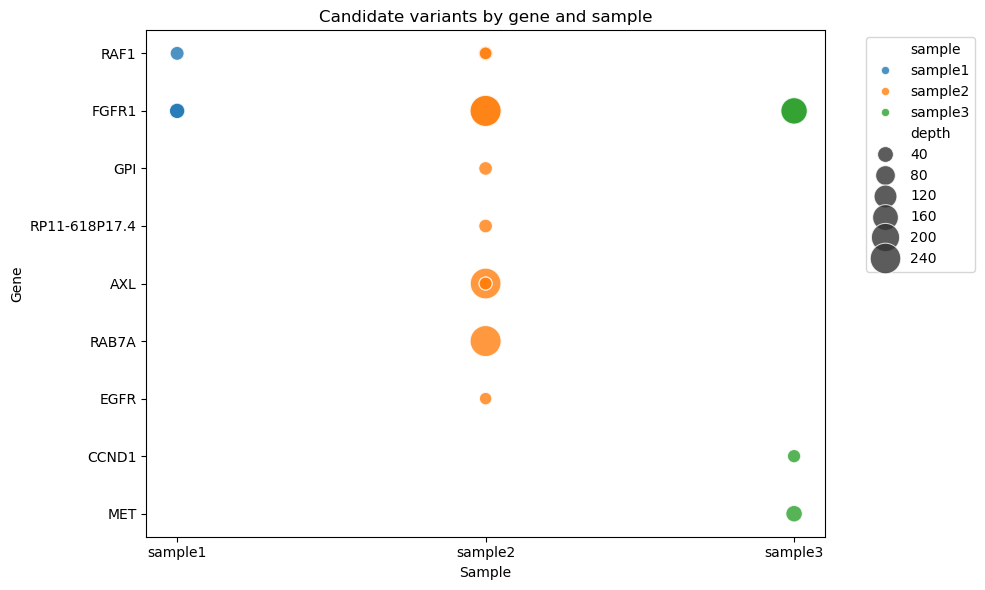

In [17]:
plot_df = variant_annot.copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="sample",
    y="gene_name",
    size="depth",
    hue="sample",
    sizes=(80, 500),
    alpha=0.8
)

plt.title("Candidate variants by gene and sample")
plt.xlabel("Sample")
plt.ylabel("Gene")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(
    fig_dir / "candidate_variants_by_gene_sample.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3 main take aways so far: 
- sample2 has the broadest variant burden
- FGFR1 appears across all samples
- sample3 has fewer but notable calls in CCND1/MET/FGFR1.

### Variant Interpretation Summary

Candidate variants localized predominantly to highly enriched targeted genes identified earlier in the enrichment analysis, including **FGFR1, AXL, RAF1, EGFR, MET, CCND1, and RAB7A**.

The strongest recurrent signal occurred within **FGFR1**, where identical adjacent substitutions were detected across all three samples with high read depth and strong quality support. Additional variants appeared sample-specific, including **AXL**, **RAB7A**, and **EGFR** variants enriched primarily within sample2 and **CCND1** and **MET** variants identified within sample3.

sample3 exhibited substantial amplification redundancy during molecule-aware QC analysis. Because of that - despite the presence of several high-depth candidate variants, interpretation of variant support within sample3 should be performed cautiously because amplification bias may inflate apparent read support.

### Limitations

I want to include the several limitations that should be considered when interpreting these candidate variants:

- The data derive from targeted RNA sequencing rather than matched DNA sequencing.
- Allele-specific expression and transcript abundance can bias observed variant frequencies.
- RNA editing and reverse-transcription artifacts may generate apparent nucleotide substitutions.
- PCR amplification redundancy, particularly in sample3, may inflate apparent support for some variants.
- No matched normal control was available to distinguish somatic mutations from germline polymorphisms.

Therefore, the variants identified here should be interpreted as exploratory candidate events requiring orthogonal validation.